In [12]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [13]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets         import make_classification

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.svm            import SVC
from sklearn.metrics        import classification_report
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier

# hyperopt 용
from hyperopt               import hp


# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

In [14]:
# 결과받을 딕셔너리
results = {}

In [15]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [16]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [17]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [18]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [19]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [20]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [21]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_over, y_over, size=0.4)

In [22]:
# 6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# 모델별 스페이스 생성
randomforest_search_space = {
    'n_estimators': hp.quniform('n_estimators', 200, 800, 50),
    'max_depth': hp.choice('max_depth', [None] + list(range(5, 21, 3))),
    'min_samples_split': hp.quniform('min_samples_split', 2, 12, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 6, 1),
    'max_features': hp.choice('max_features', ['sqrt', 'log2']),
    'bootstrap': hp.choice('bootstrap', [True, False]),
}
def process_rf_params(params):
    return {
        'n_estimators': int(params['n_estimators']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'max_depth': params['max_depth'],  # choice는 그대로 넣어도 됨
        'max_features': params['max_features'],
        'bootstrap': params['bootstrap'],
        'random_state': 42,
        'n_jobs': -1  # CPU 풀가동
    }

randomforest = RandomForestClassifier()

# 파라미터 지정
best_params, best_randomforest, trials, exec_time = tuner.tune(
    randomforest, X_tr, y_tr, X_val, y_val, randomforest_search_space
)

# best모델 결과 출력
model_name = 'rf_ho_best'
results[model_name] = uu.get_model_train_eval(
    best_randomforest, model_name, X_train, X_test, y_train, y_test, best_params
)


RandomForestClassifier 튜닝 시작
  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'
Error in objective function: int() argument must be a string, a bytes-like objec

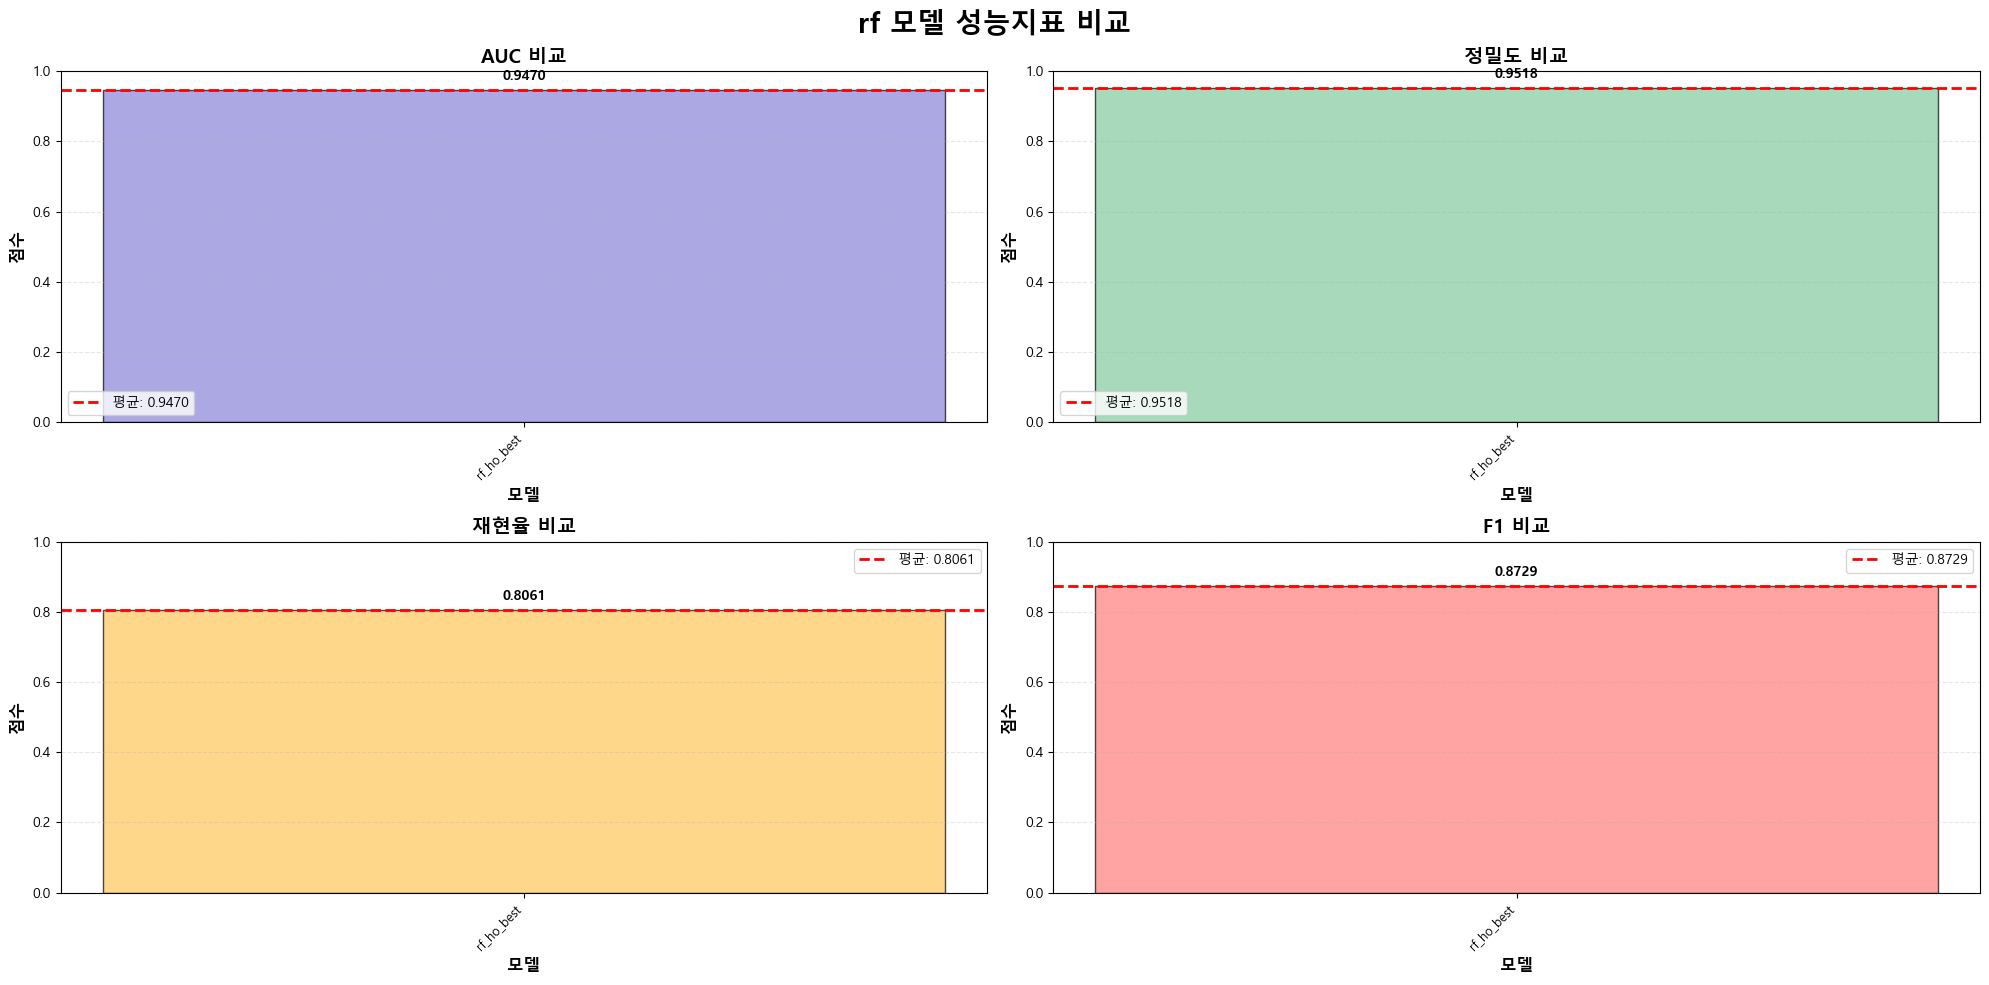


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9470 (rf_ho_best)
  최저: 0.9470 (rf_ho_best)
  평균: 0.9470
  표준편차: nan

[정밀도]
  최고: 0.9518 (rf_ho_best)
  최저: 0.9518 (rf_ho_best)
  평균: 0.9518
  표준편차: nan

[재현율]
  최고: 0.8061 (rf_ho_best)
  최저: 0.8061 (rf_ho_best)
  평균: 0.8061
  표준편차: nan

[F1]
  최고: 0.8729 (rf_ho_best)
  최저: 0.8729 (rf_ho_best)
  평균: 0.8729
  표준편차: nan


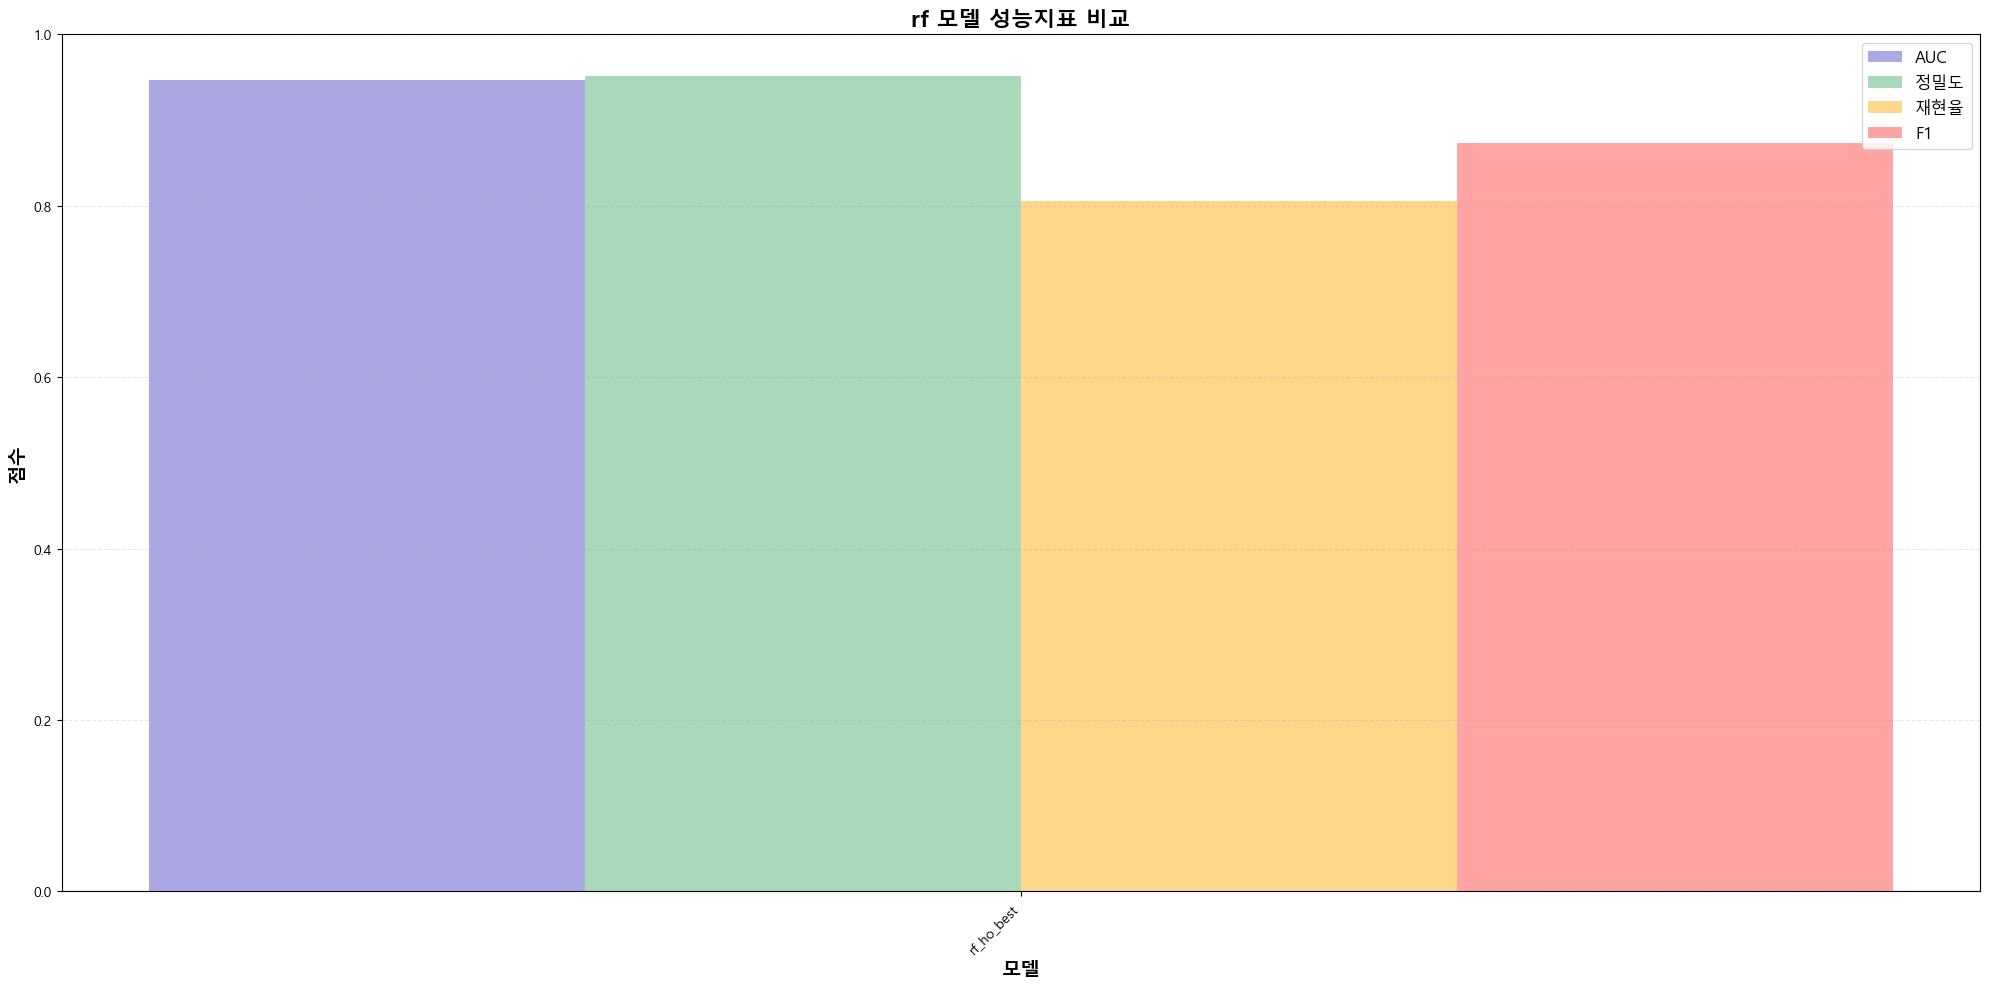


=== F1 Score 기준 상위 5개 모델 ===
              AUC     정밀도     재현율      F1
rf_ho_best  0.947  0.9518  0.8061  0.8729

그래프가 저장되었습니다: ../images/rf_모델_성능지표_비교_2025_1128.png


In [23]:
# 7 시각화
mo.model_metrics_graph(results, 'rf 모델 성능지표 비교')

In [24]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기 
# X_train_scaled, X_test_scaled, scaler = pp.scale_data(X_train, X_test)

In [25]:
mlp_search_space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', [
        (50,),
        (100,),
        (100, 50),
        (150, 100, 50)
    ]),
    'activation': hp.choice('activation', ['relu', 'tanh']),
    'solver': hp.choice('solver', ['adam', 'sgd']),
    'alpha': hp.loguniform('alpha', -5, -1),  # L2 regularization (1e-5 ~ 1e-1)
    'learning_rate_init': hp.uniform('learning_rate_init', 0.0001, 0.01),
    'batch_size': hp.choice('batch_size', [32, 64, 128]),
    'max_iter': hp.quniform('max_iter', 100, 500, 50)
}